## Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling (20 pts)

**Resources:**
- LDA:
    - https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06 
    - https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
    - https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/ 
- BERTopic:
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly 
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html 


In [2]:
import sys
print(sys.executable)
import spacy
nlp = spacy.load("en_core_web_sm")
print(nlp.pipe_names)



/srv/conda/envs/sotu/bin/python
['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [3]:
from spacy import displacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.gensim_models
import spacy
import pandas as pd

from tqdm import tqdm
from collections import Counter


nlp = spacy.load("en_core_web_sm")


import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-dark')

# read in SOTU.csv
sou = pd.read_csv('data/SOTU.csv')


### LDA

- Train an LDA model with 18 topics
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization

You may use the next two cells to process the data.

In [4]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [5]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

To train an LDA model, use the LdaModel function that we imported a couple of cells back. The last resource linked under the LDA section is especially useful for walking through the steps we have below. *Note: one of the arguments to the LdaModel function is `random_state` which specifies the random seed for reproducibility. Please set yours to 42. Further, the last resource provided uses `LdaMulticore` which is essentially a parallelizable version of our function `LdaModel`. Use `LdaModel` instead, but the usage will be similar, except you can ignore the `iterations` and `workers` arguments..*.

In [6]:
# Build dictionary from processed_docs, which is a list of tokens extracted from our speeches
dictionary = Dictionary(processed_docs)
# Here I convert to the bag of words corpus
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]


In [7]:
# train LDA model with 18 topics
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=18, random_state=42, passes=10)


In [12]:
# print the top 10 words for each topic

print("--- LDA Topics ---")

for topic_id, topic_str in lda_model.print_topics(num_topics=-1):
    print(f"Topic: {topic_id} \nWords: {topic_str}\n")


--- LDA Topics ---
Topic: 0 
Words: 0.013*"states" + 0.013*"government" + 0.009*"united" + 0.008*"congress" + 0.007*"country" + 0.006*"year" + 0.006*"public" + 0.006*"great" + 0.005*"state" + 0.005*"power"

Topic: 1 
Words: 0.002*"year" + 0.002*"people" + 0.002*"government" + 0.001*"states" + 0.001*"congress" + 0.001*"country" + 0.001*"nation" + 0.001*"great" + 0.001*"time" + 0.001*"united"

Topic: 2 
Words: 0.003*"year" + 0.003*"government" + 0.002*"states" + 0.002*"congress" + 0.002*"united" + 0.002*"people" + 0.002*"great" + 0.002*"service" + 0.002*"public" + 0.001*"increase"

Topic: 3 
Words: 0.015*"year" + 0.011*"world" + 0.011*"people" + 0.011*"america" + 0.010*"nation" + 0.007*"help" + 0.007*"congress" + 0.007*"american" + 0.007*"work" + 0.006*"time"

Topic: 4 
Words: 0.009*"isthmus" + 0.006*"colombia" + 0.005*"government" + 0.004*"states" + 0.004*"panama" + 0.004*"united" + 0.004*"colombian" + 0.004*"treaty" + 0.003*"year" + 0.003*"congress"

Topic: 5 
Words: 0.003*"year" + 0.0

In [13]:
# print the topic distribution for the first speech
from numpy import float32

dominant_topic = max(lda_model.get_document_topics(corpus[0]), key=lambda x: x[1])

# Format as expected
formatted_output = [(dominant_topic[0], float32(dominant_topic[1]))]
print(formatted_output)



[(7, np.float32(0.9997309))]


In [14]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()

lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

lda_vis


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.162521 -0.126311       1        1  35.438083
6      0.157323 -0.060432       2        1  25.787725
10     0.178967  0.028782       3        1  13.735866
3      0.202841  0.134162       4        1  12.638032
7      0.168056  0.166615       5        1   7.052381
8      0.155744 -0.155774       6        1   5.078049
16     0.000794  0.007825       7        1   0.169912
17    -0.053576  0.027428       8        1   0.029613
9     -0.058696 -0.027552       9        1   0.027767
4     -0.041461 -0.041372      10        1   0.024963
12    -0.061192 -0.032978      11        1   0.005718
1     -0.128475  0.030088      12        1   0.001699
2     -0.057389  0.009090      13        1   0.001699
5     -0.115087  0.007610      14        1   0.001699
13    -0.091102  0.005346      15        1   0.001699
11    -0.125912 -0.003683      16        1   0.001699
15    -0.136505  0.010673      17        1   0.001699
14    -0.156851  0.020482      18        1   0.001699, topic_info=            Term         Freq        Total Category  logprob  loglift
1525  government  8290.000000  8290.000000  Default  30.0000  30.0000
1066      states  6520.000000  6520.000000  Default  29.0000  29.0000
1250        year  7007.000000  7007.000000  Default  28.0000  28.0000
223     congress  5396.000000  5396.000000  Default  27.0000  27.0000
1185      united  5054.000000  5054.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
141     business     0.005015  1490.473949  Topic18  -7.9191  -1.6192
1009     service     0.005552  2173.415605  Topic18  -7.8174  -1.8947
1417  department     0.005227  1752.772929  Topic18  -7.8778  -1.7400
801        peace     0.005108  1994.063468  Topic18  -7.9008  -1.8920
5000     subject     0.005067  1983.383843  Topic18  -7.9089  -1.8947

[1383 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
9256      4  0.982066  --to
9084      4  0.984218  --we
9111      1  0.814738  1791
9111      4  0.101842  1791
9111      6  0.101842  1791
...     ...       ...   ...
1250      5  0.100321  year
1250      6  0.027114  year
1250      7  0.000571  year
1250      8  0.000143  year
1250     10  0.000143  year

[2020 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 7, 11, 4, 8, 9, 17, 18, 10, 5, 13, 2, 3, 6, 14, 12, 16, 15])

### BERTopic

- Train a BERTopic model with a `min_topic_size` of 3 *Hint: use `BERTopic` to instantiate the model and specify `min_topic_size` in here. Actually fit the model using `fit_transform`, which `docs` passed into this.*
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization of the topics (see topic_model.visualize_topics())

In [ ]:
docs = sou['Text'].to_list()

In [17]:
# train the model - this takes about 30 seconds

# remove stop words from the topics (Hint: use CountVectorizer and then .update_topics on topic_model)
##
##

docs = sou['Text'].to_list()


# Instantiate the BERTopic model (remove random_state)
topic_model = BERTopic(min_topic_size=3)

# Fit the model to your documents
topics, probs = topic_model.fit_transform(docs)

# OPTIONAL: remove stop words from the topics
vectorizer_model = CountVectorizer(stop_words="english")
topic_model.update_topics(docs, vectorizer_model=vectorizer_model)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
# output the top 10 words for each topic - hint see get_topic_info
##
##

# Get topic information
topic_info = topic_model.get_topic_info()

# Loop through topics (excluding -1 if you want to skip outliers)
for topic_id in topic_info['Topic']:
    if topic_id == -1:
        continue  # skip outlier topic if desired
    print(f"Topic {topic_id}: {topic_model.get_topic(topic_id)}\n")


Topic 0: [('world', np.float64(0.019228347899678977)), ('people', np.float64(0.01727447896622444)), ('american', np.float64(0.015970483259994776)), ('new', np.float64(0.015911970627819426)), ('america', np.float64(0.015120572733323352)), ('years', np.float64(0.015037881288040449)), ('year', np.float64(0.013278447371668828)), ('nation', np.float64(0.012077178317849647)), ('congress', np.float64(0.011997215164747572)), ('americans', np.float64(0.011856644954904056))]

Topic 1: [('america', np.float64(0.029309814270261254)), ('americans', np.float64(0.020407332985916488)), ('tonight', np.float64(0.0194494221644573)), ('american', np.float64(0.01935569474075681)), ('people', np.float64(0.01911048165519914)), ('new', np.float64(0.017069574848884137)), ('years', np.float64(0.015189017749020466)), ('world', np.float64(0.014753785278996592)), ('know', np.float64(0.014131563409158566)), ('thats', np.float64(0.014000243718538818))]

Topic 2: [('states', np.float64(0.020690041488251393)), ('gover

In [22]:
# output the topic distribution for the first speech
# hint: check out approximate_distribution() and visualize_distribution()

##
##
# First document/topic
first_doc = docs[0]

# Get approximate topic distribution (unpack the tuple)
dist, _ = topic_model.approximate_distribution(first_doc)
print(dist)

[[0.12348505 0.17751238 0.01985987 0.15954975 0.02938956 0.01256997
  0.02102503 0.01655994 0.01973017 0.0188038  0.02462197 0.05498707
  0.14316374 0.02053036 0.0122153  0.03025366 0.0224875  0.020762
  0.02222775 0.02663675 0.01733539 0.00629298]]


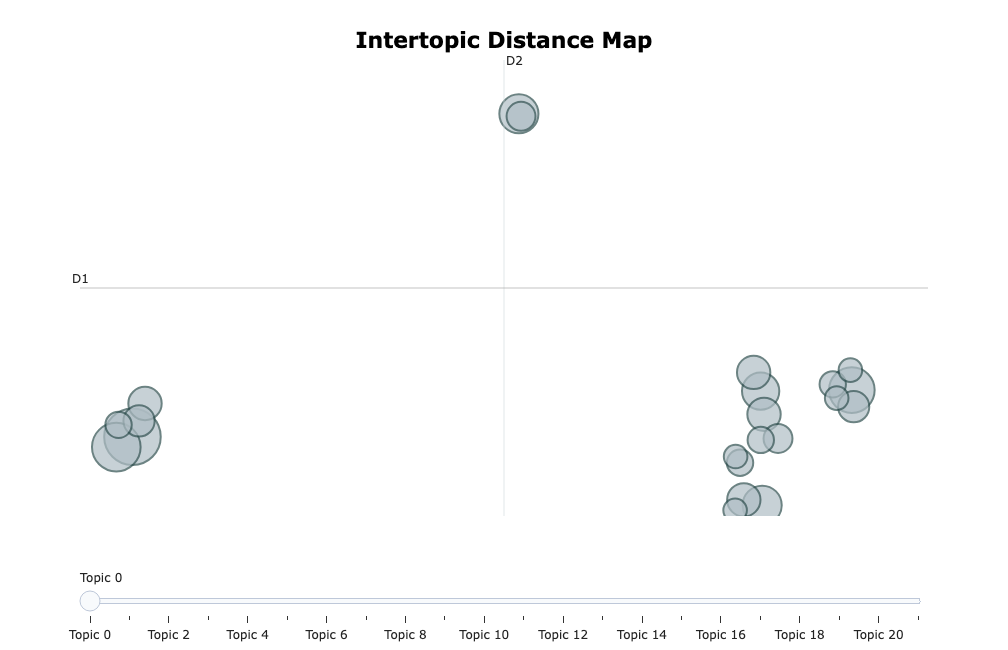

In [23]:
# run this cell to visualize the topics
topic_model.visualize_topics()